# `geom_smiley()` — Comprehensive Test Notebook

https://github.com/gr13nka/lets-plot


Manual QA notebook for the `geom_smiley` geom. Covers all aesthetics, parameters, layout features, edge cases, and cross-platform testing.

## 1. Setup

In [1]:
%pip install --force-reinstall ./SmileyWheel/lets_plot-4.8.3.dev1-cp312-cp312-linux_x86_64.whl

Defaulting to user installation because normal site-packages is not writeable
Processing ./SmileyWheel/lets_plot-4.8.3.dev1-cp312-cp312-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 239.1 MB/s  0:00:00
  Attempting uninstall: pypng
    Found existing installation: pypng 0.20220715.0
    Uninstalling pypng-0.20220715.0:
      Successfully uninstalled pypng-0.20220715.0
  Attempting uninstall: pillow
    Found existing installation: pillow 12.1.1
    Uninstalling pillow-12.1.1:
      Successfully uninstalled pillow-12.1.1
  Attempting uninstall: palettable90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [pillow]
    Found existing installation: palettable 3.3.3━━━━━━━━━━━━━ 1/4 [pillow]
    Uninstalling palettable-3.3.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [pillow]
      Successfully uninstalled palettable-3.3.3━━━━━━━━━━━━━━━ 1/4 [pillow]
  Attempting uninstall: lets-plot╺━━━━━━━━━━━━━━━━━━━ 2/4 [palettable]
    Found existing installation: lets-plot 4.8.3.dev1━━━━━━━━━ 2/4 [p


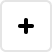
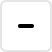
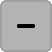
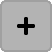
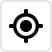
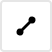
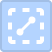
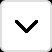
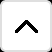
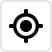
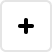
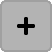
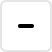
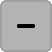
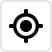
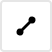
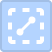
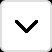
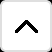
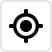

In [2]:
from pyexpat import features

from lets_plot import *
LetsPlot.setup_html(offline=True)

In [3]:
data = {'x': [1, 2, 3], 'y': [1, 2, 1]}
ggplot(data, aes('x', 'y')) + geom_smiley() + ggtitle('Default aesthetics') + flavor_darcula()

In [4]:
ggplot() + \
    geom_smiley(aes('x', 'y'), data={'x': [1], 'y': [1]}, happiness=1.0, size=10, fill='#6BCB77', color='black') + \
    geom_smiley(aes('x', 'y'), data={'x': [2], 'y': [2]}, happiness=0.0, size=10, fill='#FFD93D', color='black') + \
    geom_smiley(aes('x', 'y'), data={'x': [3], 'y': [1]}, happiness=-1.0, size=10, fill='#FF6B6B', color='black') + \
    ggtitle('Different happiness per smiley (separate layers)')

## 3. Happiness Parameter

`happiness` controls mouth curvature: -1.0 (sad) to 1.0 (smile). Default is 0.5.

It can be used both as a **fixed geom parameter** (`geom_smiley(happiness=...)`) and as a **mapped aesthetic** (`aes(happiness='col')`).

When both are present, the mapped aesthetic takes precedence.

In [5]:
d1 = {'x': [1,2,3], 'y': [1,1,1], 'h': [1,0,-1]}

ggplot(d1, aes('x', 'y', happiness='h')) + \
geom_smiley(size=12, fill='yellow', color='black')

In [6]:
# Default happiness (no parameter)
ggplot(d1, aes('x', 'y')) + \
    geom_smiley(size=15, fill='yellow', color='black') + \
    ggtitle('Default happiness (0.5)')

In [7]:
# Extreme values beyond [-1, 1]
d1 = {'x': [1,2,3], 'y': [1,1,1], 'h': [8,0.00000000000000001,-10]}

ggplot(d1, aes('x', 'y', happiness='h')) + \
geom_smiley()

## 4. Fixed Aesthetics

All aesthetics are set as fixed values.

### 4a. Color

In [8]:
data4 = {'x': [1, 2, 3, 4], 'y': [1, 2, 1, 2]}

gggrid([
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(color='red') + \
        ggtitle('color=red'),
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(color='black') + \
        ggtitle('color=blue'),
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(color='green') + \
        ggtitle('color=green'),
])

### 4b. Fill

In [9]:
gggrid([
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(fill='lightgreen') + \
        ggtitle('fill=lightgreen'),
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(fill='gold') + \
        ggtitle('fill=gold'),
    ggplot(data4, aes('x', 'y')) + \
        geom_smiley(fill='#FF6B6B') + \
        ggtitle('fill=#FF6B6B'),
])

### 4c. Size

In [10]:
data_size = {'x': [1, 2, 3], 'y': [1, 1, 1]}

gggrid([
    ggplot(data_size, aes('x', 'y')) + \
        geom_smiley(size=5) + \
        ggtitle('size=5'),
    ggplot(data_size, aes('x', 'y')) + \
        geom_smiley(size=10) + \
        ggtitle('size=10'),
    ggplot(data_size, aes('x', 'y')) + \
        geom_smiley(size=20) + \
        ggtitle('size=20'),
])

### 4d. Linewidth

In [11]:
data_linewidth = {'x': [1, 2, 3], 'y': [1, 1, 1]}

gggrid([
    ggplot(data_linewidth, aes('x', 'y')) + \
        geom_smiley(linewidth=0.5) + \
        ggtitle('linewidth=0.5'),
    ggplot(data_linewidth, aes('x', 'y')) + \
        geom_smiley(linewidth=1.5) + \
        ggtitle('linewidth=1.5'),
    ggplot(data_linewidth, aes('x', 'y')) + \
        geom_smiley(linewidth=3.0) + \
        ggtitle('linewidth=3.0'),
])

### 4e. Alpha

In [12]:
data_alpha = {'x': [1, 2, 3], 'y': [1, 1, 1]}

gggrid([
    ggplot(data_alpha, aes('x', 'y')) + \
        geom_smiley(alpha=0.2, fill='black', color='white') + \
        ggtitle('alpha=0.2'),
    ggplot(data_alpha, aes('x', 'y')) + \
        geom_smiley(alpha=0.5, fill='black', color='white') + \
        ggtitle('alpha=0.5'),
    ggplot(data_alpha, aes('x', 'y')) + \
        geom_smiley(alpha=1.0, fill='black', color='white') + \
        ggtitle('alpha=1.0'),
])

### 4f. All Fixed Aesthetics Together

In [13]:
ggplot({'x': [1, 2, 3, 4], 'y': [1, 2, 3, 2]}, aes('x', 'y')) + \
    geom_smiley(
        color='red', fill='blue', size=12, linewidth=2, alpha=0.2,
        happiness=-1
    ) + \
    ggtitle('All fixed: color, fill, size, linewidth, alpha, happiness')

### 4g. `happiness` as an Aesthetic Mapping

In [14]:
data_happiness_map = {
    'x': [1, 2, 3],
    'y': [1, 1, 1],
    'h': [1.0, 0.0, -1.0]
}

ggplot(data_happiness_map, aes('x', 'y', happiness='h')) + \
    geom_smiley(size=12, fill='yellow', color='black') + \
    ggtitle('Mapped happiness: aes(happiness="h")')

### 4h. Mapping Precedence over Fixed `happiness=`

In [15]:
data_happiness_precedence = {
    'x': [1, 2, 3],
    'y': [1, 1, 1],
    'h': [-1.0, 0.0, 1.0]
}

ggplot(data_happiness_precedence, aes('x', 'y', happiness='h')) + \
    geom_smiley(happiness=0.8, size=12, fill='#FFD93D', color='black') + \
    ggtitle('Mapped happiness overrides fixed happiness=0.8')

## 5. Standard Parameters

### 5a. Position Adjustments

In [16]:
data_pos = {'x': [1, 1, 2, 2], 'y': [1, 1, 2, 2]}

gggrid([
    ggplot(data_pos, aes('x', 'y')) + \
        geom_smiley() + \
        ggtitle('identity (overlapping)'),
    ggplot(data_pos, aes('x', 'y')) + \
        geom_smiley(position=position_nudge(x=0.1, y=0.1)) + \
        ggtitle('position_nudge'),
    ggplot(data_pos, aes('x', 'y')) + \
        geom_smiley(position=position_jitter(width=0.1, height=0.1)) + \
        ggtitle('position_jitter'),
])

### 5b. show_legend

In [17]:
data_leg = {'x': [1, 2, 3], 'y': [1, 2, 1]}

gggrid([
    ggplot(data_leg, aes('x', 'y')) + \
        geom_smiley(manual_key='Smiley', show_legend=True) + \
        ggtitle('show_legend=True'),
    ggplot(data_leg, aes('x', 'y')) + \
        geom_smiley(manual_key='Smiley', show_legend=False) + \
        ggtitle('show_legend=False'),
])

#### Bug found & fixed: `show_legend=False` ignored for `manual_key` legends

**Symptom:** Both plots above show the yellow-square legend entry, even the one with `show_legend=False`.

**Root cause:** The legend assembly pipeline has two independent code paths in
`PlotAssemblerUtil.createLegends()` (`plot-builder/.../assemble/PlotAssemblerUtil.kt`):

1. **Mapped-aesthetic legends** (line 42) — calls `mappedRenderedAesToCreateGuides()`, which checks
   `layer.isLegendDisabled` at the top and returns an empty list when `true`
   (`PlotGuidesAssemblerUtil.kt:21-27`). This path correctly suppresses legends.

2. **Custom legends via `manual_key`** (line 112) — processes `layerInfo.customLegendOptions` and
   calls `LegendAssembler.addCustomLayer()`. This path **did not** check `isLegendDisabled` at all,
   so `show_legend=False` was silently ignored whenever `manual_key` was set.

The Python wrapper is correct — `geom_smiley(..., show_legend=False)` emits `"show_legend": false` in
the JSON spec. `LayerConfig.isLegendDisabled` reads it correctly. The flag propagates through
`GeomLayerBuilder.disableLegend()` into `GeomLayerInfo.isLegendDisabled`. The bug is exclusively in
the consumer: `PlotAssemblerUtil` skipped the check for the custom-legend branch.

**Fix** (one line, `PlotAssemblerUtil.kt:113`):

```kotlin
// BEFORE (broken):
layerInfo.customLegendOptions?.let { legendOptions ->

// AFTER (fixed):
if (!layerInfo.isLegendDisabled) layerInfo.customLegendOptions?.let { legendOptions ->
```

**Call-chain reference:**

```
Python: geom_smiley(show_legend=False)
  -> JSON spec: { "show_legend": false }
  -> LayerConfig.isLegendDisabled  (plot-stem/.../config/LayerConfig.kt:92)
  -> PlotGeomTilesUtil: layerBuilder.disableLegend(...)  (plot-stem/.../front/tiles/PlotGeomTilesUtil.kt:214)
  -> GeomLayerBuilder.myIsLegendDisabled  (plot-builder/.../assemble/GeomLayerBuilder.kt:113)
  -> GeomLayerInfo.isLegendDisabled  (plot-builder/.../assemble/tiles/GeomLayerInfo.kt:15)
  -> PlotGuidesAssemblerUtil.mappedRenderedAesToCreateGuides()  :  checked (line 21)
  -> PlotAssemblerUtil custom legend block                      :  NOW checked (line 113)
```

### 5c. manual_key

In [18]:
ggplot(data, aes('x', 'y')) + \
    geom_smiley(manual_key='Smiley') + \
    ggtitle('manual_key legend label')

### 5d. sampling

In [19]:
import random
random.seed(42)
n = 100
data_samp = {'x': [random.gauss(0, 1) for _ in range(n)],
             'y': [random.gauss(0, 1) for _ in range(n)]}

gggrid([
    ggplot(data_samp, aes('x', 'y')) + \
        geom_smiley(size=5) + \
        ggtitle(f'All {n} points'),
    ggplot(data_samp, aes('x', 'y')) + \
        geom_smiley(size=5, sampling=sampling_random(20)) + \
        ggtitle('sampling_random(20)'),
])

### 5f. Tooltips

In [20]:
data_tt = {'name': ['Alice', 'Bob', 'Carol'], 'x': [1, 2, 3], 'y': [1, 2, 1]}

ggplot(data_tt, aes('x', 'y')) + \
    geom_smiley(
        tooltips=layer_tooltips().line('@name')
    ) + ggtitle('Custom tooltips (hover to see name)')

## 6. Interaction With Other Layers

In [21]:
data6 = {'x': [1, 2, 3, 4, 5], 'y': [2, 3, 1, 4, 2]}

gggrid([
    ggplot(data6, aes('x', 'y')) + \
        geom_smiley(size=15,) + \
        geom_point(size=3, color='red') + \
        ggtitle('geom_smiley + geom_point on top'),
    ggplot(data6, aes('x', 'y')) + \
        geom_line(color='steelblue', size=2) + \
        geom_smiley(size=8, fill='blue', color='white', happiness=0.6) + \
        ggtitle('geom_line behind geom_smiley'),
])

In [22]:
# ggmarginal with histogram
ggplot(data_samp, aes('x', 'y')) + \
    geom_smiley(size=4) + \
    ggmarginal('tr', layer=geom_histogram(color='black')) + \
    ggtitle('ggmarginal with histogram')

## 7. Layout Features

### 7a. facet_wrap

In [23]:
data_facet = {
    'x': [1, 2, 3, 1, 2, 3],
    'y': [1, 2, 1, 2, 1, 2],
    'cat': ['A', 'A', 'A', 'B', 'B', 'B']
}

ggplot(data_facet, aes('x', 'y')) + \
    geom_smiley() + \
    facet_wrap('cat') + \
    ggtitle('facet_wrap by category')

### 7b. coord_flip

In [24]:
ggplot(data, aes('x', 'y')) + \
    geom_smiley() + \
    coord_flip() + \
    ggtitle('coord_flip')

### 7c. ggtb (toolbar for pan/zoom)

In [25]:
ggplot(data, aes('x', 'y')) + \
    geom_smiley() + \
    ggtb() + \
    ggtitle('Pan/zoom toolbar — try dragging')

### 7d. ggsize

In [26]:
gggrid([
    ggplot(data, aes('x', 'y')) + \
        geom_smiley() + \
        ggsize(200, 200) + ggtitle('200x200'),
    ggplot(data, aes('x', 'y')) + \
        geom_smiley() + \
        ggsize(400, 200) + ggtitle('400x200'),
])

This is the expected behaviour, the ggsize should be ignored.

### 7e. gggrid (multi-panel)

In [27]:
gggrid([
    ggplot(d1, aes('x', 'y')) + geom_smiley(happiness=-0.8, size=12, fill='#FF6B6B', color='black') + ggtitle('Sad'),
    ggplot(d1, aes('x', 'y')) + geom_smiley(happiness=0.0, size=12, fill='#FFD93D', color='black') + ggtitle('Neutral'),
    ggplot(d1, aes('x', 'y')) + geom_smiley(happiness=0.8, size=12, fill='#6BCB77', color='black') + ggtitle('Happy'),
    ggplot(d1, aes('x', 'y')) + geom_smiley(happiness=0.5, size=12, fill='#4D96FF', color='black') + ggtitle('Default'),
], ncol=2)

## 8. Edge Cases / Tests

### 8a. Empty data

In [28]:
ggplot({'x': [], 'y': []}, aes('x', 'y')) + \
    geom_smiley(size=10) + \
    ggtitle('Empty data — should show empty plot')

### 8b. Single data point

In [29]:
ggplot({'x': [0], 'y': [0]}, aes('x', 'y')) + \
    geom_smiley() + \
    ggtitle('Single point')

### 8c. NaN/None in x, y

In [30]:
import math

data_nan = {'x': [1, 2, None, 4], 'y': [1, math.nan, 3, 4]}
ggplot(data_nan, aes('x', 'y')) + \
    geom_smiley(size=10, fill='yellow', color='black') + \
    ggtitle('NaN/None — should skip missing, show 2 smileys')

### 8d. Large number of points (50+)

In [31]:
import random
random.seed(123)
n_large = 600
data_large = {
    'x': [random.uniform(0, 10) for _ in range(n_large)],
    'y': [random.uniform(0, 10) for _ in range(n_large)]
}
ggplot(data_large, aes('x', 'y')) + \
    geom_smiley(size=3) + \
    ggtitle(f'{n_large} smileys')

### 8e. Overlapping points at same position

In [32]:
data_overlap = {'x': [1, 1, 1], 'y': [1, 1, 1]}

gggrid([
    ggplot(data_overlap, aes('x', 'y')) + \
        geom_smiley(alpha=0.5) + \
        ggtitle('3 overlapping (alpha=0.5)'),
    ggplot(data_overlap, aes('x', 'y')) + \
        geom_smiley(position=position_jitter(width=0.1, height=0.1)) + \
        ggtitle('3 jittered'),
])

### 8f. Very large/small coordinate values

In [33]:
gggrid([
    ggplot({'x': [1e6, 2e6, 3e6], 'y': [1e6, 2e6, 1e6]}, aes('x', 'y')) + \
        geom_smiley() + \
        ggtitle('Large coords (1e6)'),
    ggplot({'x': [0.001, 0.002, 0.003], 'y': [0.001, 0.002, 0.001]}, aes('x', 'y')) + \
        geom_smiley() + \
        ggtitle('Small coords (0.00x)'),
])

# Screenshoots from PlotSpecDebugger

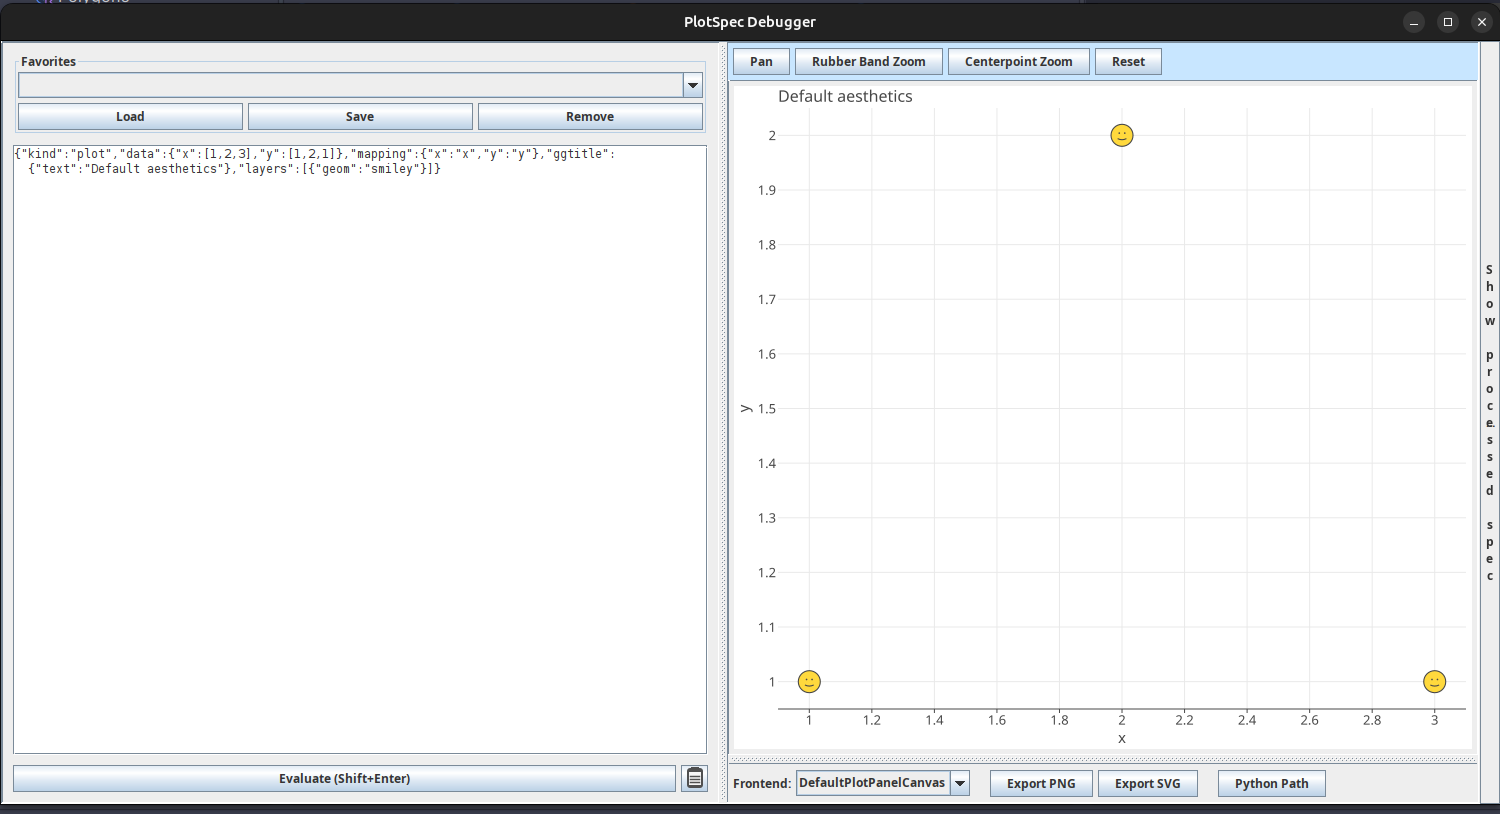

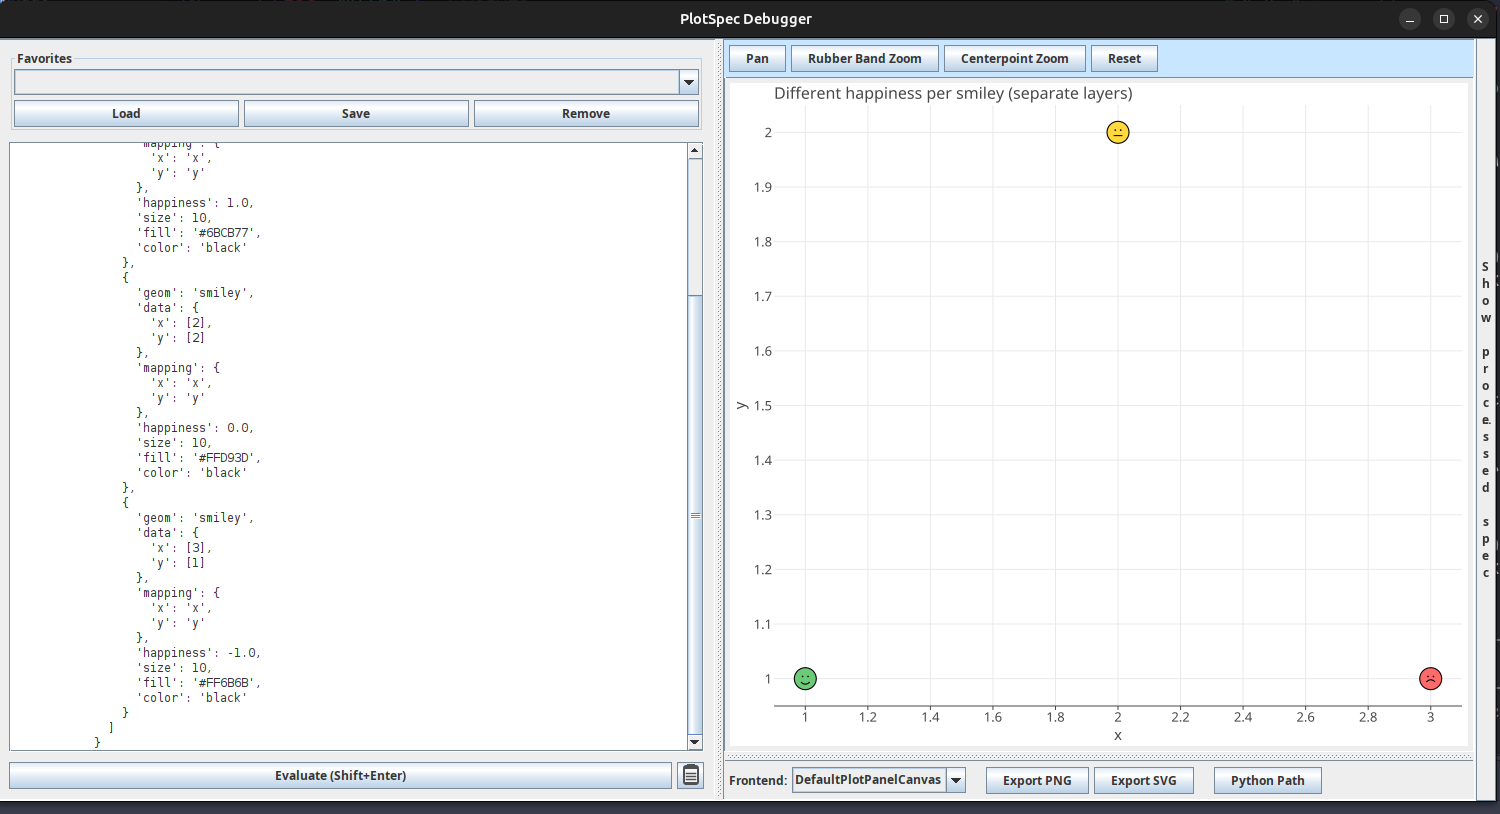

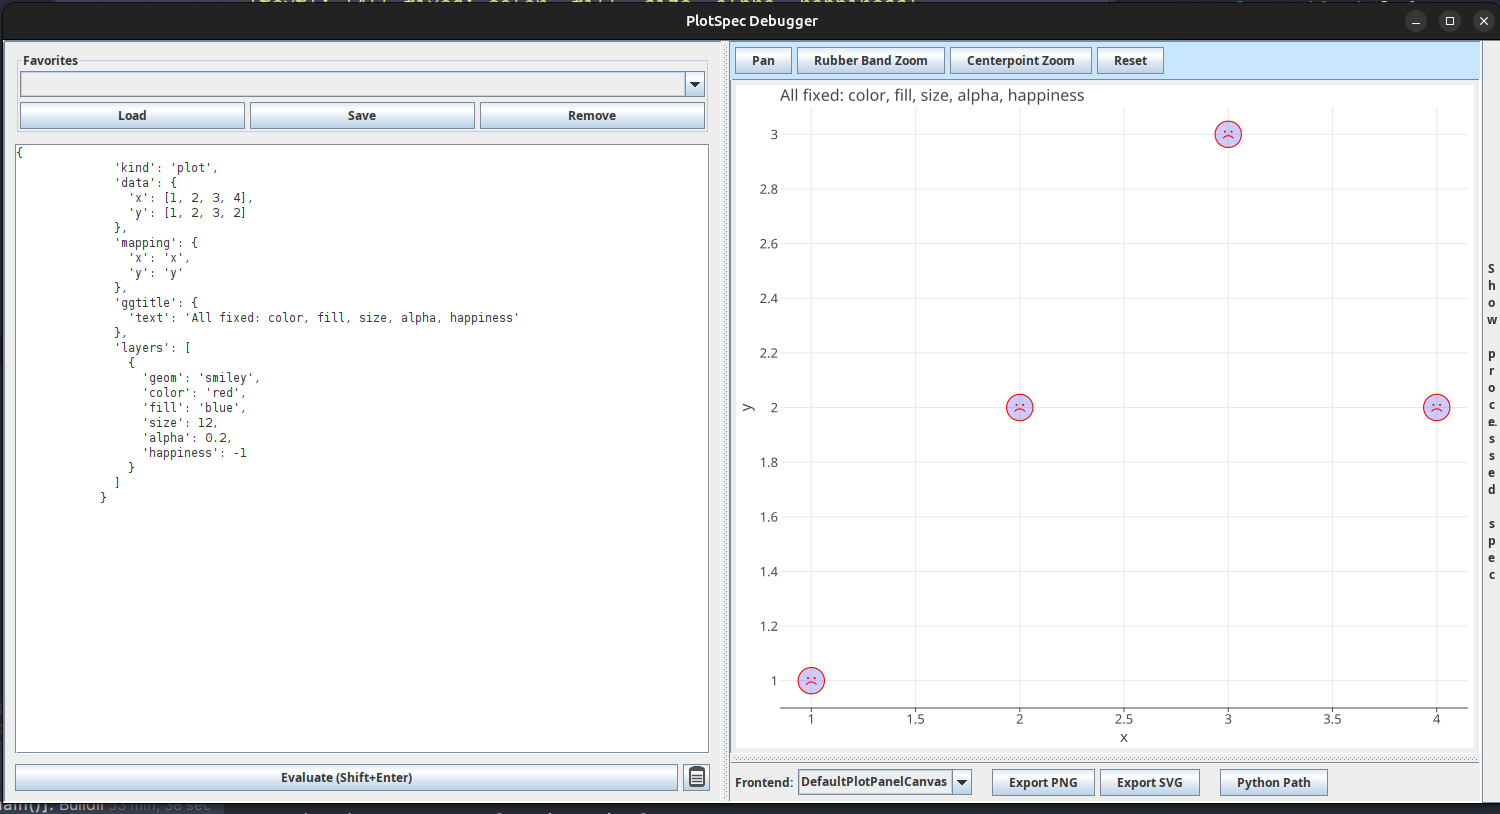

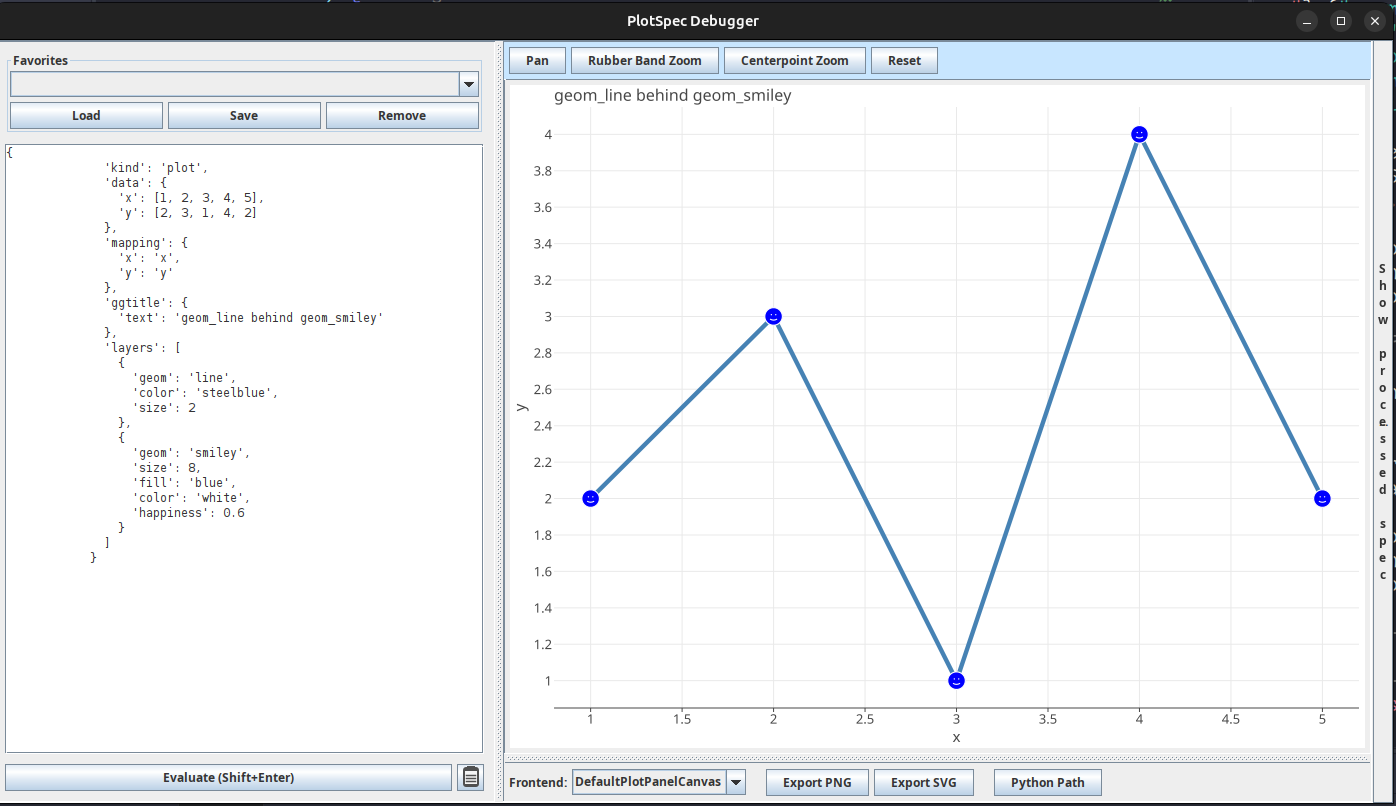

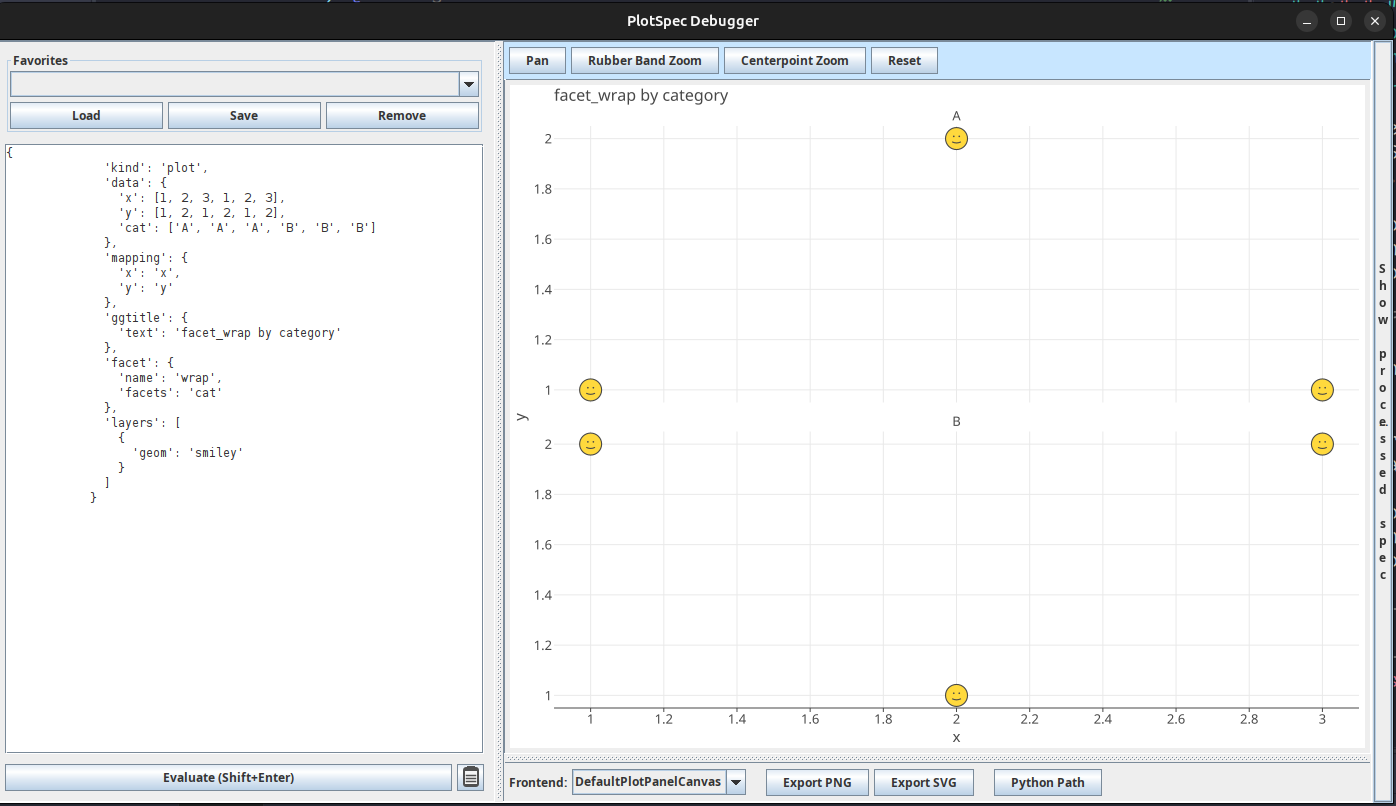